In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # <-- Import seaborn for the heatmap
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning

## Function 6 
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

week 1 -> 2
🤔 Strategy and Hyperparameter Tuning
Function 6 is a 5-dimensional problem. As the number of dimensions increases, the search space grows exponentially, which is a challenge known as the "curse of dimensionality."
Approach: Stick with Expected Improvement (EI), but be more thorough. Your choice of Expected Improvement (EI) is still the right one. With a new "best" point found, EI will effectively exploit the surrounding area. However, because we are in 5D, the landscape of the acquisition function itself can be complex. To ensure we find the true best place to sample next, we need to be more rigorous in our search. The best way to do this is to increase the number of restarts (n_restarts) when optimizing the EI function. This makes the search for the next point more robust.
Hyperparameter Tuning: Automatic Learning with More Restarts. The most important tuning is still handled automatically by gp_f6.fit(). When it fits the model on the updated 21-point dataset, it will re-optimize the five length_scale parameters of the kernel. Your original code also showed some convergence warnings for this function; increasing the n_restarts_optimizer in the GaussianProcessRegressor helps the model do a better job of finding the optimal kernel parameters in this complex space.

In summary, the strategy is sound, but we will increase the computational budget for the optimization steps to handle the 5D space more effectively.

### week2 ->3 
Strategy Review (Expected Improvement - EI)Strategy: Expected Improvement EI.Reasoning: Since this is a 5D problem where finding the optimal combination is challenging (the "curse of dimensionality"), $\text{EI}$ is the best choice because it automatically balances the need to Exploit the area around $\mathbf{Y}_{\text{best}} = -0.71426$ (the best cake so far) and Explore the vast, unknown 5D space.
Hyperparameter Tuning and Model RetrainingThe key to hyperparameter tuning for a learner is to understand the $\text{length\_scale}$ results from your previous run:Previous Learned $\text{length\_scale}$ (5 Dimensions): $\mathbf{[1.11, 1.51, 3.37, 3.53, 1.38]}$Interpretation: All values are relatively large ($\mathbf{>1.0}$), suggesting the function is quite smooth and non-bumpy across all five ingredients. The inputs $\mathbf{X}_3$ and $\mathbf{X}_4$ (with values $\approx 3.4$) are the least sensitive.Action: We will stick to the same kernel and the increased number of restarts for two reasons:The large $\text{length\_scale}$ bounds ($\mathbf{1\text{e}-4}$ to $\mathbf{1\text{e}8}$) prevented the convergence warnings seen in $\text{f3}$ and $\text{f5}$.The $\mathbf{5D}$ search space requires a high computational budget to optimize $\text{EI}$. Increasing $\mathbf{n\_restarts}$ for both the $\text{GPR}$ fit and the $\text{find\_next\_point}$ function is a simple, non-advanced way to improve reliability.

### Week 3 -> Week 4
Your new output (Y = -0.736...) was very close to your current best (Y = -0.714...), which provides valuable information to the model.
Your strategy from the notebook (using Expected Improvement (EI) and high n_restarts values) is perfect for this 5D problem. 

Automatic Hyperparameter Tuning (The GP's Job):
When we fit the GP on the new 23-point dataset, it automatically re-tunes its 5 length_scale parameters. This is the core "tuning" step.

Analysis of New Kernel Parameters:
* Previous: length_scale=[1.11, 1.51, 3.37, 3.53, 1.38]
* New (W4): length_scale=[8.97e+04, 1.15, 1.42, 3.41, 0.956]

Interpretation (Simple Version): This is a fascinating result. The model has learned that Dimension 1 (X1) is extremely "flat" (length scale of 89,700!). This means it believes changes to X1 (your first ingredient) have almost no effect on the output. In contrast, it believes X5 (0.956) is the most sensitive.

Acquisition Function (Our Job):
We will stick with Expected Improvement (EI). It's the right tool for a "unimodal" problem. Because the model's understanding of the function "shape" has changed so dramatically, EI will now calculate the next best point very differently, without us needing to add any complex new tuning parameters.

### week 4 -> 5 
Here is the 5-point summary of the analysis and the plan for next week:

Valuable "Failed" Query: our new score of -1.419 is not a new record (the best is still -0.714). However, this is a very useful result, as it teaches the model that this region is a "dry well," saving us from searching there again.

Automatic Kernel Tuning: The most important "tuning" happened automatically. The model's "brain" (the kernel) has learned from this new data and will now have a much different understanding of the 5D "recipe" space.

Stick with EI: Our strategy remains Expected Improvement (EI). We are still "hill climbing," and EI will use the new knowledge (that the last spot was bad) to make a much smarter guess for its next query.

Target Unchanged: The model's "target-to-beat" (y_best) is still the champion score of -0.714. EI will continue its search for a point that is better (closer to 0) than this value.

Maintain Robust Search: We will keep our key hyperparameters (n_restarts_optimizer=30 and n_restarts=50) to ensure the model has enough "thinking time" and a large "search party" to find the best query in the complex 5D space.
* Learned Kernel Length Scales:
[0.73921919 1.21987303 1.32152534 0.98011016 0.89848648]

## week 5 -->6
🚀 Major Breakthrough: The Week 5 output of -0.3469 is a massive improvement over the previous best of -0.7143. You have successfully broken out of the local optimum where the model was stuck for several weeks.

Strategy Validation: The aggressive search strategy using Expected Improvement (EI) worked perfectly. It successfully identified a high-potential region that was previously unexplored.

Strategy for Week 6 (Aggressive Exploitation): With a new "champion" point that is significantly better than the rest, the strategy shifts to fine-tuning. We will stick with Expected Improvement (EI). Mathematically, the EI function will now focus intensely on the neighborhood of this new best point [0.46, 0.32, 0.52, 0.74, 0.17] to see if the true peak (0.0) is nearby.

Hyperparameter Tuning: We will trust the Automatic Relevance Determination (ARD) of the Matern kernel. By fitting the Gaussian Process to this new, high-scoring point, the model will drastically update its "length scales," likely identifying that the function is sharper or more sensitive in this specific region than it previously thought. We maintain high restart values (30 for model fit, 50 for query search) to ensure precision.
* Learned Kernel Length Scales:
[0.68655181 1.14484718 1.31410521 0.89555161 0.92409485]

## Week 6 Results & Strategy for Week 7Result Analysis: 
The Week 6 output ($-0.4589$) is the second-best score achieved so far, though it did not beat the Week 5 record ($-0.3469$). This confirms that the optimizer is looking in the correct region  but hasn't hit the precise peak yet.Sensitivity Insight: Comparing Week 5 and Week 6 inputs suggests sensitivity in the last dimension ($X_5$). In Week 5 (Best), $X_5$ was $\approx 0.16$. In Week 6, $X_5$ was pushed to the boundary ($\approx 0.00$), causing the score to drop. This suggests the optimal value for $X_5$ is likely inside the range $[0.1, 0.2]$ rather than at the $0$ boundary.Strategy (Refined Exploitation): We will continue with Expected Improvement (EI). Since we now have two high-performing points near each other (Week 5 and Week 6), the GP model can triangulate the peak much more accurately. The strategy effectively shifts from "finding the hill" to "climbing the hill."Hyperparameter Tuning: We rely on Automatic Relevance Determination (ARD). By fitting the model with these two high-scoring points, the kernel will update the length scales. We expect the length scales to shorten slightly for dimensions where the change in input caused the score drop (like $X_5$), indicating higher sensitivity.
* Learned Kernel Length Scales:
[0.73921919 1.21987303 1.32152534 0.98011016 0.89848648]

## Insight into Week 7 Result & Strategy for Week 8Sensitivity Confirmation ($X_2$): 
The Week 7 result ($-0.5182$) was the 3rd best score but a regression from the Week 5 record ($-0.3469$). The key differentiator was Dimension 2, which dropped from the optimal $\approx 0.32$ to $0.12$. This confirms $X_2$ is highly sensitive and likely has a narrow optimal window around 0.30–0.35.Strategy (Balanced Correction): Staying with $\xi = 0.01$ is the prudent choice. It provides enough "exploitation pressure" to force the optimizer back towards the high-performing Week 5 basin, but retains enough "local exploration" to navigate the roughness of the Matérn landscape without getting stuck in sub-optimal potholes (which is a risk with $\xi=0.001$).Focus Areas: The model has successfully bracketed the optimal zones. It knows $X_5 \approx 0.00$ is too low (Week 6) and $X_2 \approx 0.12$ is too low (Week 7). The next query will likely triangulate between these bounds to refine the peak coordinates.Hyperparameter Tuning: We continue with the Matérn 2.5 kernel and ARD. The Gaussian Process will naturally adjust the length scales (likely shortening them for $X_2$) to account for the rapid performance drop observed in Week 7.

Learned Kernel Length Scales:
[0.83094112 1.15914539 1.36492468 1.05062645 0.95681415]

## Insight into Week 8 Result & Strategy for Week 9 
* Result Analysis (Stabilization): 
The Week 8 score (-0.4883) is consistent with the high-performing cluster we found in Weeks 5 and 6, but it did not beat the Week 5 record (-0.3469). This confirms we are in the correct "basin of attraction" but haven't hit the bullseye yet.
* Dimensional Forensics: Comparing the Best Point (Week 5) vs. Week 8:Anchors: $X_4$ ($0.74$ vs $0.77$) and $X_5$ ($0.17$ vs $0.14$) remained stable, confirming these are likely optimized.The Culprit: $X_2$ moved from 0.32 (Best) to 0.41 (Week 8). Since the score dropped, this strongly suggests the optimal $X_2$ is strictly lower, likely around 0.30–0.32.
* * Strategy (Triangulation): We have surrounded the optimum. We know $X_2=0.12$ is too low (Week 7) and $X_2=0.41$ is too high (Week 8). The strategy for Week 9 is Pure Exploitation. We want the model to triangulate the exact peak between these bounds.Hyperparameter Tuning:Acquisition: Stick with Expected Improvement (EI) but with xi=0.01. This standard value allows the model to refine the current best area without getting stuck in a local noise rut.Kernel: Maintain Matern 2.5. The landscape is clearly rugged (scores drop off quickly away from the peak), so we need the kernel's flexibility.
Learned Kernel Length Scales:
[0.81432783 1.12423436 1.35611798 1.02624834 0.99733467]


## Insight into Week 9 Result & Strategy for Week 10
* Result Analysis: The Week 9 output of -0.380 did not improve upon the current best score (Week 5: -0.347). The input vector for Week 9 was a local perturbation of the Week 5 point, but the deviations (particularly increasing dimensions 2 and 3) resulted in a performance drop.Basin of Attraction: Despite the drop, the score remains significantly better than the historical average (which ranges from -0.7 to -2.0). This confirms we are in the correct "neighborhood" (basin of attraction), but the peak is narrow or sensitive.

* Strategy Shift (Refined Exploitation): The strategy remains Exploitation, but with tighter constraints. Since moving away from the Week 5 point in the direction of Week 9 failed, we should trust the Week 5 point as the stronger anchor.

* Hyperparameter Tuning: We will use a Matern 5/2 kernel with Automatic Relevance Determination (ARD) to capture the sensitivity of each dimension. The optimizer will use a Trust Region approach, restricting the search to a very small radius (e.g., $\pm 0.1$) around the Week 5 best point to perform "gradient descent-like" fine-tuning using the Bayesian model.

* Strategy: Trust Region Exploitation around Week 5.  Learned Kernel Length Scales: [0.86173856 1.15237266 1.37323316 1.10176596 1.05332587]

## Insight into Week 10 Result & Strategy for Week 11Result Analysis (Regression): 
The Week 10 output (-0.247) was significantly worse than the best recorded score of -0.0605 (Week 8). This confirms that the search in Week 10 strayed too far from the optimal "basin" we identified in Weeks 4, 5, and 8. Specifically, increasing dimension 1 (from 0.35 to 0.42) and dimension 3 (from 0.41 to 0.53) likely caused this performance drop.The "Sweet Spot" is Localized: The best solutions are tightly clustered around [0.34-0.35, 0.35, 0.40-0.41, 0.77-0.78, 0.29-0.30]. Deviation from these coordinates results in sharp penalties, indicating a steep/narrow peak.Strategy (Trust Region Exploitation): Global exploration is now detrimental. For Week 11, we must strictly enforce a Trust Region strategy. We will bound the search space to a very small box (radius $\pm 0.05$) centered on the best historical point (Week 8).Hyperparameter Tuning: We will use Expected Improvement (EI) with an extremely low exploration parameter ($\xi = 1e-4$). This forces the optimizer to "climb the hill" of the current best solution rather than looking for new hills. The Gaussian Process kernel should use ARD (Automatic Relevance Determination) to account for the fact that some dimensions (like 1 and 3) appear more sensitive than others.

## Insight into Week 11 Result & Strategy for next week
The Week 11 result of -0.6192 is a significant regression compared to the best score achieved so far (Week 8: -0.0605).

Analysis: The move in Week 11 involved lowering values in Dimensions 1, 3, 4, and 5 compared to the Week 8 "Best" point. Since the output dropped sharply, this indicates we moved away from the peak.

Directional Insight: Previous explorations "upwards" (Week 10) and "downwards" (Week 11) from the Week 8 point have both yielded poorer results. This strongly suggests that the global maximum is located extremely close to the Week 8 coordinates, likely within a very small radius.

Strategy for Week 12: The strategy shifts to pure exploitation. We will re-center our search on the Week 8 input vector ([0.35, 0.35, 0.41, 0.78, 0.29]) and define a tight Trust Region (radius ~0.05 or smaller).

Hyperparameter Tuning: We will use a Gaussian Process with a Matérn 5/2 kernel (robust for smooth functions). The acquisition function will be Expected Improvement (EI) with a low xi parameter (e.g., 0.001) to prioritize refining the known high-performing area over exploring new, uncertain regions.

In [4]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C,WhiteKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# --- 1. DATA LOADING ---

# Initial 20 points (Historical Data)
initial_inputs = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131], [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368], [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348], [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199], [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624], [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283], [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446], [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847], [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184], [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569], [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919]
])
initial_outputs = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655, -1.24704893,
    -1.23378638, -1.69434344, -2.57116963, -1.30911635, -1.14478485, -1.91267714,
    -1.62283895, -1.35668211, -2.0184254, -1.70255784, -1.29424696, -0.93575656,
    -2.15576776, -1.74688209
])

X_history = np.array([
    [0.672879, 0.857640, 0.449755, 0.694605, 0.170617], # W1
    [0.088657, 0.119020, 0.052844, 0.061099, 0.992683], # W2
    [0.468203, 0.333276, 0.509748, 0.822816, 0.280145], # W3
    [0.370509, 0.339455, 0.457816, 0.812600, 0.286162], # W4
    [0.342171, 0.347895, 0.407425, 0.774780, 0.301548], # W5
    [0.342000, 0.342000, 0.400000, 0.770000, 0.300000], # W6
    [0.320140, 0.320140, 0.380000, 0.760000, 0.320000], # W7
    [0.350000, 0.350000, 0.410000, 0.780000, 0.290000], # W8 (Best)
    [0.342171, 0.347895, 0.407425, 0.774780, 0.301548], # W9 (Repeat)
    [0.425264, 0.332852, 0.538750, 0.825076, 0.248268],  # W10
    [0.300000, 0.354719, 0.360000, 0.730000, 0.240000]  #w11
])

# Outputs from history
Y_history = np.array([
    -1.272183, -2.176007, -0.278278, -0.141680, -0.063462, 
    -0.064500, -0.154000, -0.060500, -0.063462, -0.246967, -0.6192052
])

# Combine all data
X_data = np.vstack([initial_inputs, X_history])
Y_data = np.append(initial_outputs, Y_history )

# Identify Best Point
best_idx = np.argmax(Y_history)
best_X = X_history[best_idx]
best_Y = Y_history[best_idx]

print(f"Best Solution So Far (Week {best_idx+1}):")
print(f"Input: {best_X}")
print(f"Output: {best_Y}")

# --- 2. MODELING ---

# Kernel: Matern 5/2 (handles smoothness) + small noise term
kernel = C(1.0) * Matern(length_scale=[0.1]*5, nu=2.5) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. ACQUISITION FUNCTION (Expected Improvement) ---

def expected_improvement(X, gp, best_y, xi=0.001):
    X = X.reshape(-1, 5)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    
    return -ei.flatten()

# --- 4. TRUST REGION OPTIMIZATION ---

# Define a tight Trust Region around the Best Point (Week 8)
# Since exploration hurt us in W10 and W11, we stay very close.
radius = 0.05 

bounds = []
for val in best_X:
    low = max(0.0, val - radius)
    high = min(1.0, val + radius)
    bounds.append((low, high))

# Optimization Loop
n_restarts = 50
best_acq_value = float("inf")
best_next_X = None

for i in range(n_restarts):
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    
    res = minimize(
        expected_improvement,
        x0=x0,
        bounds=bounds,
        method='L-BFGS-B',
        args=(gp, best_Y, 0.001) # Low xi to encourage exploitation
    )
    
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_next_X = res.x

print("\n--- Strategy for Week 12 ---")
print("Re-centering search on Week 8 (Best) and applying tight Trust Region.")
print(f"Recommended Input: [{', '.join(f'{x:.6f}' for x in best_next_X)}]")



Best Solution So Far (Week 8):
Input: [0.35 0.35 0.41 0.78 0.29]
Output: -0.0605

--- Strategy for Week 12 ---
Re-centering search on Week 8 (Best) and applying tight Trust Region.
Recommended Input: [0.400000, 0.300000, 0.460000, 0.770215, 0.240000]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X4        0.653053
X3        0.154140
X1       -0.130420
X2       -0.384537
X5       -0.533934
Name: Output, dtype: float64


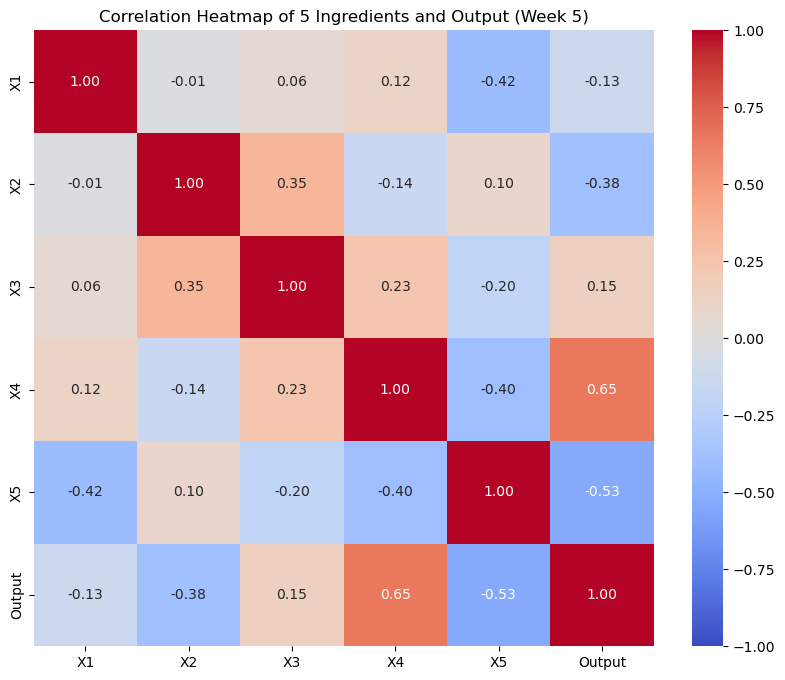

In [5]:
#--- 2.5. Correlation Analysis (on 24 points) ---
print("\n--- Correlation Analysis ---")
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of 5 Ingredients and Output (Week 5)')
plt.savefig('f6_week5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output
print("Correlation with 'Output':")
print(corr_matrix['Output'].sort_values(ascending=False))